In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns

In [3]:
from google.colab import files
import pandas as pd

files.upload()
data=pd.read_stata('binary.dta')
print(data.shape)
data.head()

Saving binary.dta to binary.dta
(400, 4)


,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [4]:
data.isnull().sum()

,0
admit,0
gre,0
gpa,0
rank,0


In [5]:
features=['gre','gpa','rank']
x=data[features]
y=data['admit']

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=5)
display(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(320, 3)

(320,)

(80, 3)

(80,)

In [7]:
model=LogisticRegression(solver='lbfgs',max_iter=1000)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [8]:
model=LogisticRegression(solver='lbfgs',max_iter=1000)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=metrics.accuracy_score(y_test,y_pred)
print('Accuracy Score:',accuracy)
print('Accuracy in Percentage:',int(accuracy*100),'%')

Accuracy Score: 0.6625
Accuracy in Percentage: 66 %


<Axes: xlabel='Predicted', ylabel='Actual'>

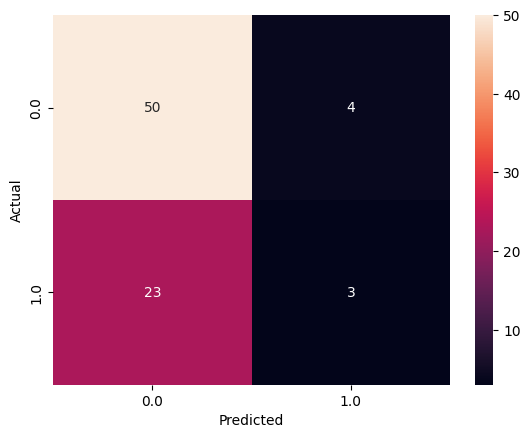

In [9]:
conf_mat=pd.crosstab(y_test,y_pred,rownames=['Actual'],colnames=['Predicted'])
sns.heatmap(conf_mat,annot=True,fmt='d')